# **MNIST OU - Measures of Quality**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
import sys, os
sys.path.append(os.getcwd())

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models


In [ ]:
!pip install torchmetrics
!pip install torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.7 MB/s eta 0:00:00


## Imports

In [ ]:
import os
import sys

import torch
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Subset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Resize, Compose

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

from src.metrics import (
    to_01_range,
    inception_uint8,
    load_saved_samples,
    bpd_probability_flow_ode,
)

from src.score_model import ScoreNet
from src.ou_schedules import (
    make_ou_process_functions,
    make_ou_probability_flow_drift,
)

## Basic configuration

In [ ]:
if torch.cuda.is_available():
    device_str = "cuda"
elif torch.backends.mps.is_available():
    device_str = "mps"
else:
    device_str = "cpu"

device = torch.device(device_str)
print("Device:", device)

n_threads = torch.get_num_threads()
print("Number of threads:", n_threads)

_ = torch.manual_seed(123)

Device: cuda
Number of threads: 6


## Load Dataset

In [ ]:
transform = Compose([
    Resize((32, 32)),
    ToTensor(),
    Normalize((0.5,), (0.5,))
])

data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

digit = 3
indices_digit = torch.where(data.targets == digit)[0]
data_train = Subset(data, indices_digit)

print(type(data_train))
print("Number of images:", len(data_train))

<class 'torch.utils.data.dataset.Subset'>
Number of images: 6131


## Measure models and samplers

In [ ]:
schedules = ["linear", "cosine", "sigmoid"]
epochs = [10, 20, 50, 100, 200, 500]

sampler_keys = ["final_images_em", "final_images_ode", "final_images_pc"]

sampler_names = {
    "final_images_em": "em",
    "final_images_ode": "ode",
    "final_images_pc": "pc",
}

# BPD configuration
n_bpd_images = min(2000, len(data_train))
bpd_batch_size = 32
bpd_n_steps = 500

results = []

for schedule_name in schedules:
    sched = make_ou_process_functions(schedule_name)

    for epoch in epochs:
        sample_file = f"./samples/mnist_ou_{schedule_name}/final_images_epoch{epoch}.pt"
        checkpoint_path = (
            f"./checkpoints/mnist_ou_{schedule_name}/"
            f"checkpoint_ou_{schedule_name}_epoch{epoch}.pth"
        )

        if not os.path.exists(sample_file):
            print(f"Skipping OU {schedule_name} epoch {epoch}: sample file not found")
            continue

        if not os.path.exists(checkpoint_path):
            print(f"Skipping OU {schedule_name} epoch {epoch}: checkpoint not found")
            continue


        # Load trained score model for likelihood/BPD computation.
        score_model = ScoreNet(
            marginal_prob_std=sched["sigma_t"],
            in_channels=1,
            out_channels=1,
        ).to(device)

        state_dict = torch.load(checkpoint_path, map_location=device)
        score_model.load_state_dict(state_dict)
        score_model.eval()

        probability_flow_drift = make_ou_probability_flow_drift(
            schedule_dict=sched,
            score_model=score_model,
        )

        terminal_std = sched["sigma_t"](
            torch.tensor([1.0], device=device)
        ).item()

        # BPD is computed on real images using the probability flow ODE.
        # It depends on the model/checkpoint/schedule, not on the sampler.
        bpd_values = []

        for start in range(0, n_bpd_images, bpd_batch_size):
            end = min(start + bpd_batch_size, n_bpd_images)

            bpd_images = torch.stack([
                data_train[i][0] for i in range(start, end)
            ]).to(device)

            _, bpd_batch = bpd_probability_flow_ode(
                x_0=bpd_images,
                probability_flow_drift=probability_flow_drift,
                terminal_std=terminal_std,
                t_0=1.0e-3,
                t_end=1.0,
                n_steps=bpd_n_steps,
            )

            # Correction for normalized MNIST in [-1, 1]:
            # adds the constant change-of-variable/dequantization term.
            bpd_batch = bpd_batch + 7.0

            bpd_values.append(bpd_batch.detach().cpu())

        bpd_value = torch.cat(bpd_values).mean().item()

        for sampler_key in sampler_keys:
            generated_images = load_saved_samples(
                sample_file,
                sampler_key=sampler_key,
            )

            generated_images_01 = to_01_range(
                generated_images,
                assume_minus1_1=True,
            )

            target_n = generated_images_01.shape[0]

            real_images = torch.stack([
                data_train[i][0] for i in range(target_n)
            ])

            real_images_01 = to_01_range(
                real_images,
                assume_minus1_1=True,
            )

            real_u8 = inception_uint8(real_images_01).to(device)
            generated_u8 = inception_uint8(generated_images_01).to(device)

            fid_metric = FrechetInceptionDistance(
                feature=2048,
                normalize=False,
            ).to(device)

            fid_metric.update(real_u8, real=True)
            fid_metric.update(generated_u8, real=False)
            fid_value = fid_metric.compute().item()

            is_metric = InceptionScore(normalize=False).to(device)
            is_metric.update(generated_u8)
            is_mean, is_std = is_metric.compute()

            results.append({
                "schedule": schedule_name,
                "epoch": epoch,
                "sampler": sampler_names[sampler_key],
                "fid": round(fid_value, 4),
                "is_mean": round(is_mean.item(), 4),
                "is_std": round(is_std.item(), 4),
                "bpd_ode": round(bpd_value, 4),
            })


Evaluating OU linear epoch 10...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 242MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



Evaluating OU linear epoch 20...

Evaluating OU linear epoch 50...

Evaluating OU linear epoch 100...

Evaluating OU linear epoch 200...

Evaluating OU linear epoch 500...

Evaluating OU cosine epoch 10...

Evaluating OU cosine epoch 20...

Evaluating OU cosine epoch 50...

Evaluating OU cosine epoch 100...

Evaluating OU cosine epoch 200...

Evaluating OU cosine epoch 500...

Evaluating OU sigmoid epoch 10...

Evaluating OU sigmoid epoch 20...

Evaluating OU sigmoid epoch 50...

Evaluating OU sigmoid epoch 100...

Evaluating OU sigmoid epoch 200...

Evaluating OU sigmoid epoch 500...


## Show result

In [ ]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(["schedule", "epoch", "fid"]))

,schedule,epoch,sampler,fid,is_mean,is_std,bpd_ode
18,cosine,10,em,159.8380,2.0490,0.0551,3.1638
20,cosine,10,pc,167.2286,1.7613,0.0578,3.1638
19,cosine,10,ode,180.0814,2.6392,0.0797,3.1638
23,cosine,20,pc,59.6231,1.7913,0.0470,2.8291
21,cosine,20,em,89.8068,2.1733,0.0456,2.8291
22,cosine,20,ode,117.3061,2.1678,0.0735,2.8291
26,cosine,50,pc,18.2313,1.6056,0.0259,1.7048
24,cosine,50,em,36.8157,1.7783,0.0574,1.7048
25,cosine,50,ode,63.1278,1.8444,0.0524,1.7048
29,cosine,100,pc,44.6639,1.5827,0.0483,1.4774


In [ ]:
sampler_summary = (
    results_df
    .groupby("sampler")
    .agg(
        fid_mean=("fid", "mean"),
        fid_min=("fid", "min"),
        is_mean=("is_mean", "mean"),
        bpd_mean=("bpd_ode", "mean"),
    )
    .reset_index()
    .sort_values("fid_mean")
)

display(sampler_summary)

,sampler,fid_mean,fid_min,is_mean,bpd_mean
2,pc,80.239783,18.2313,1.609689,2.218572
0,em,88.539272,34.6602,1.782867,2.218572
1,ode,92.282922,28.2376,1.897133,2.218572


In [ ]:
schedule_summary = (
    results_df
    .groupby("schedule")
    .agg(
        fid_mean=("fid", "mean"),
        fid_min=("fid", "min"),
        is_mean=("is_mean", "mean"),
        bpd_mean=("bpd_ode", "mean"),
    )
    .reset_index()
    .sort_values("fid_mean")
)

display(schedule_summary)

,schedule,fid_mean,fid_min,is_mean,bpd_mean
0,cosine,69.838444,18.2313,1.773950,1.920483
1,linear,88.202706,30.0343,1.701856,2.198900
2,sigmoid,103.020828,39.3359,1.813883,2.536333


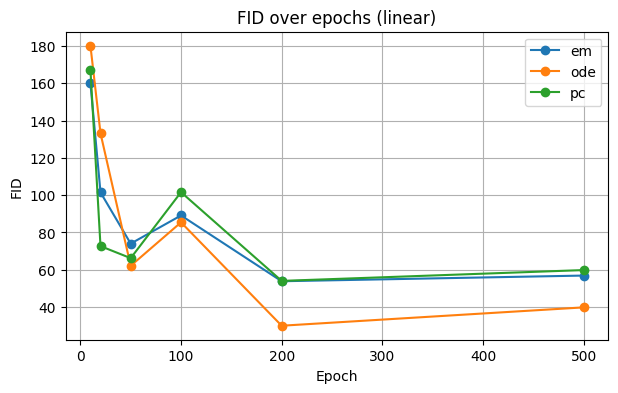

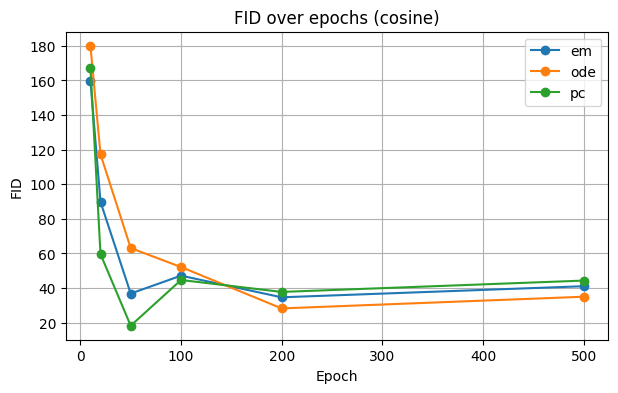

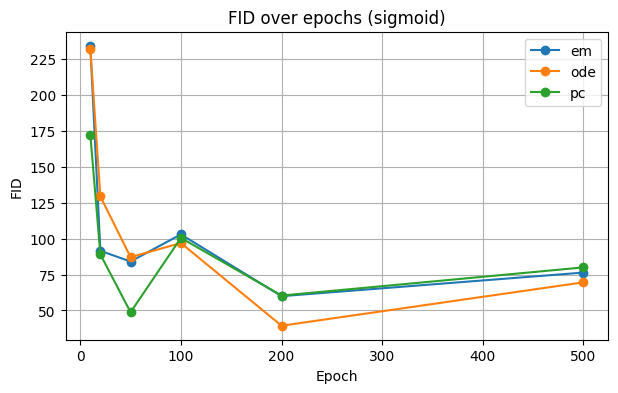

In [ ]:
for schedule_name in schedules:
    subset_schedule = results_df[results_df["schedule"] == schedule_name]

    plt.figure(figsize=(7, 4))

    for sampler in ["em", "ode", "pc"]:
        subset = subset_schedule[subset_schedule["sampler"] == sampler]
        plt.plot(subset["epoch"], subset["fid"], marker="o", label=sampler)

    plt.xlabel("Epoch")
    plt.ylabel("FID")
    plt.title(f"FID over epochs ({schedule_name})")
    plt.legend()
    plt.grid(True)
    plt.show()

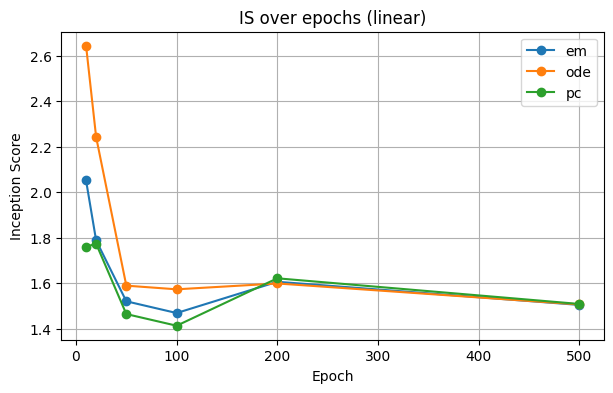

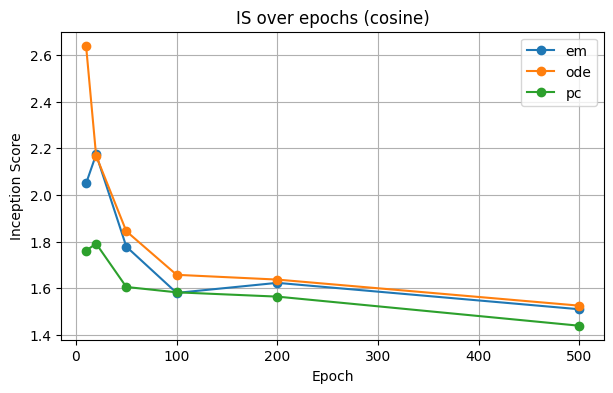

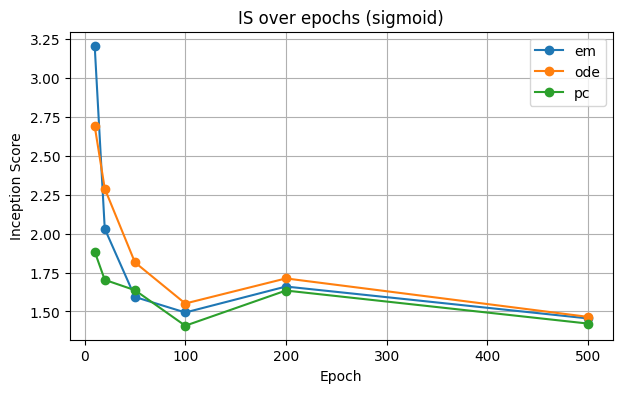

In [ ]:
for schedule_name in schedules:
    subset_schedule = results_df[results_df["schedule"] == schedule_name]

    plt.figure(figsize=(7, 4))

    for sampler in ["em", "ode", "pc"]:
        subset = subset_schedule[subset_schedule["sampler"] == sampler]
        plt.plot(subset["epoch"], subset["is_mean"], marker="o", label=sampler)

    plt.xlabel("Epoch")
    plt.ylabel("Inception Score")
    plt.title(f"IS over epochs ({schedule_name})")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
bpd_summary = (
    results_df[["schedule", "epoch", "bpd_ode"]]
    .drop_duplicates()
    .sort_values(["schedule", "epoch"])
)

display(bpd_summary)

,schedule,epoch,bpd_ode
18,cosine,10,3.1638
21,cosine,20,2.8291
24,cosine,50,1.7048
27,cosine,100,1.4774
30,cosine,200,1.0434
33,cosine,500,1.3044
0,linear,10,3.3187
3,linear,20,2.7508
6,linear,50,2.1034
9,linear,100,1.9950


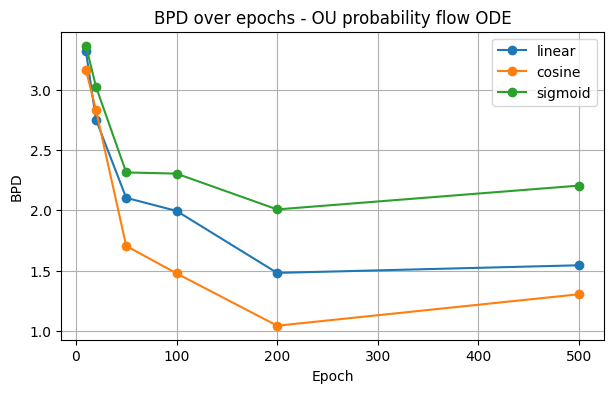

In [ ]:
plt.figure(figsize=(7, 4))

for schedule_name in schedules:
    subset = bpd_summary[bpd_summary["schedule"] == schedule_name]
    plt.plot(subset["epoch"], subset["bpd_ode"], marker="o", label=schedule_name)

plt.xlabel("Epoch")
plt.ylabel("BPD")
plt.title("BPD over epochs - OU probability flow ODE")
plt.legend()
plt.grid(True)
plt.show()